# Expense Analysis: Where Alberta's Money Is Going (2024-2029)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

sns.set_style('whitegrid')

TEAL = '#0D7377'
TEAL_LIGHT = '#7CC5C7'
CORAL = '#E8655A'
NAVY = '#14213D'
BLUE = '#2A6FA8'
GOLD = '#D4A843'
GREY = '#B0B0B0'

os.makedirs('plots', exist_ok=True)

df = pd.read_csv('expense_comparison.csv')
df.columns = df.columns.str.strip()
df['Ministry'] = df['Ministry'].str.strip()
df = df.dropna(subset=['Ministry'])
df = df[df['Ministry'] != '']

num_cols = ['2024-25_Actual', '2025-26_Budget', '2025-26_Forecast',
            '2026-27_Estimate', '2027-28_Target', '2028-29_Target',
            'Change_vs_2024', 'Pct_Change_vs_2024', 'Share_2026']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print(f'Loaded {len(df)} ministries')
print(f'Total 2026-27 Estimate: ${df["2026-27_Estimate"].sum()/1000:.1f}B')
df.head()

Loaded 26 ministries
Total 2026-27 Estimate: $78.9B


,Ministry,2024-25_Actual,2025-26_Budget,2025-26_Forecast,2026-27_Estimate,2027-28_Target,2028-29_Target,Change_vs_2024,Pct_Change_vs_2024,Share_2026
0,Advanced Education,7204,7411,7674,7738,7928,8088,534,7.4,9.8
1,Affordability and Utilities,133,168,148,153,153,153,20,15.0,0.2
2,Agriculture and Irrigation,1988,984,1704,963,906,916,-1025,-51.6,1.2
3,"Arts, Culture and Status of Women",238,226,223,199,218,237,-39,-16.4,0.3
4,Assisted Living and Social Services,10282,11298,11540,12233,12685,12787,1951,19.0,15.5


## Ministry Spending Overview

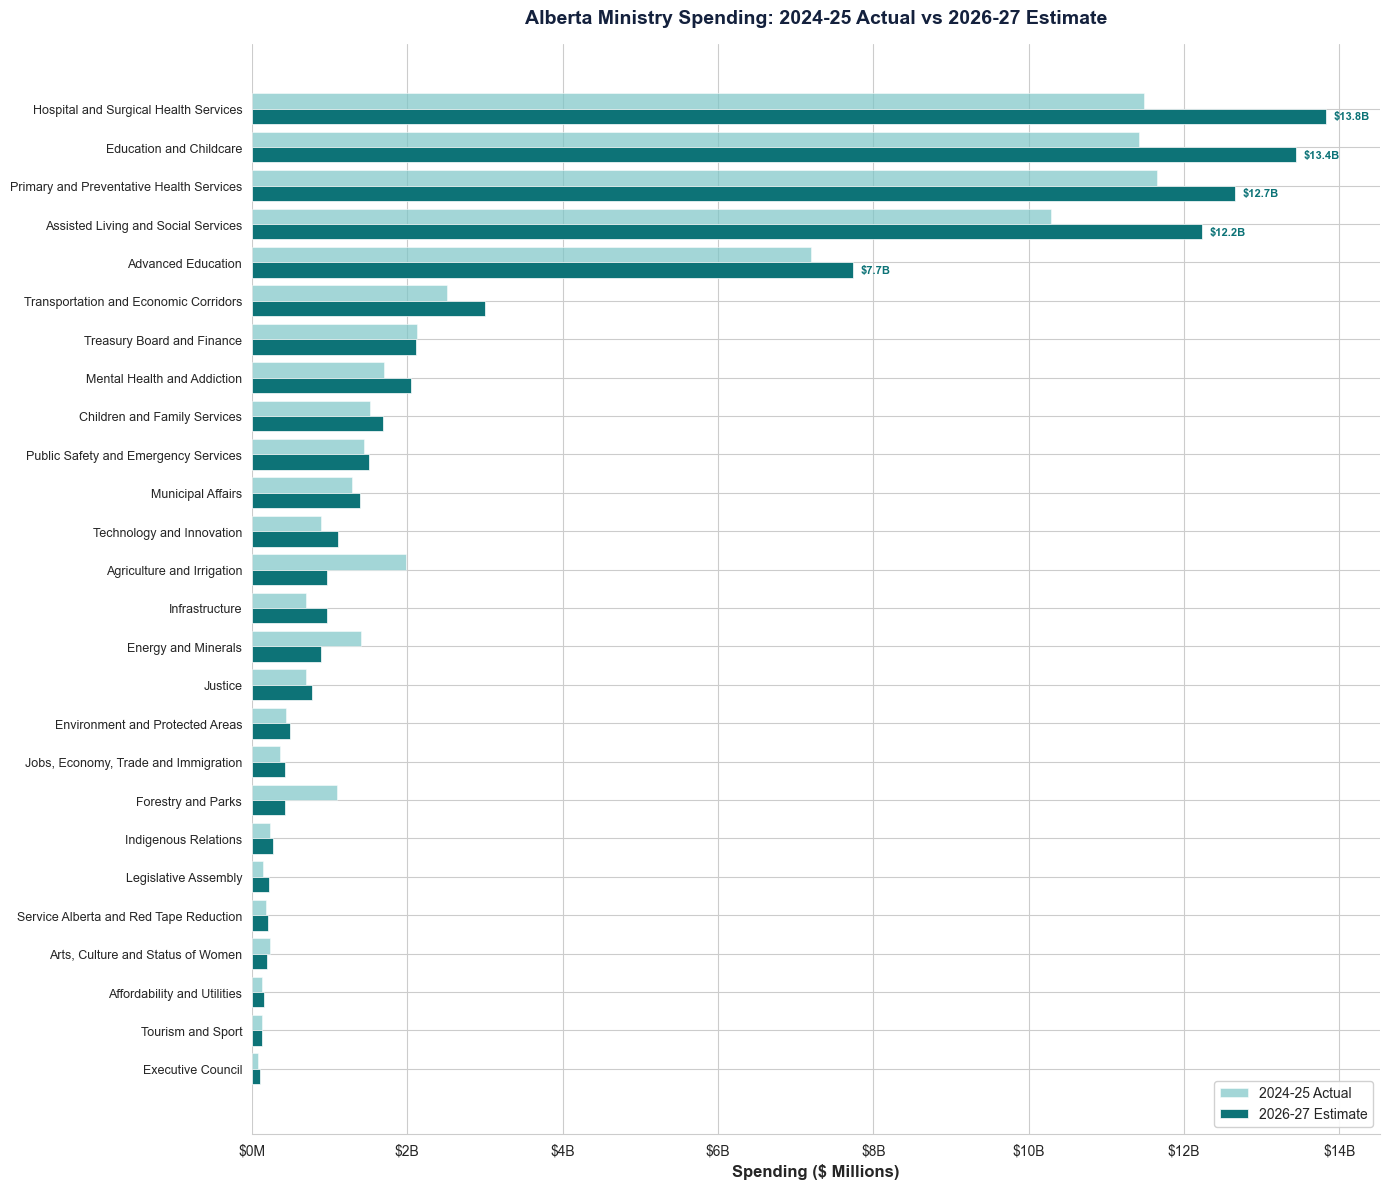

Saved: plots/expense_ministry_ranking.png


In [2]:
# Horizontal bar chart: all ministries ranked by 2026-27 estimate with 2024-25 overlay
plot_df = df.sort_values('2026-27_Estimate', ascending=True).copy()

fig, ax = plt.subplots(figsize=(14, 12))

y_pos = np.arange(len(plot_df))
bar_height = 0.4

# 2024-25 actual (lighter, behind)
ax.barh(y_pos + bar_height/2, plot_df['2024-25_Actual'], height=bar_height,
        color=TEAL_LIGHT, label='2024-25 Actual', alpha=0.7, edgecolor='white', linewidth=0.5)

# 2026-27 estimate (darker, in front)
ax.barh(y_pos - bar_height/2, plot_df['2026-27_Estimate'], height=bar_height,
        color=TEAL, label='2026-27 Estimate', edgecolor='white', linewidth=0.5)

# Annotate top 5 ministries with their 2026-27 values
top5 = plot_df.nlargest(5, '2026-27_Estimate')
for _, row in top5.iterrows():
    idx = plot_df.index.get_loc(row.name)
    ax.text(row['2026-27_Estimate'] + 100, idx - bar_height/2,
            f"${row['2026-27_Estimate']/1000:.1f}B", va='center', fontsize=8,
            fontweight='bold', color=TEAL)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['Ministry'], fontsize=9)
ax.set_xlabel('Spending ($ Millions)', fontsize=12, fontweight='bold')
ax.set_title('Alberta Ministry Spending: 2024-25 Actual vs 2026-27 Estimate',
             fontsize=14, fontweight='bold', color=NAVY, pad=15)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}B' if x >= 1000 else f'${x:.0f}M'))

sns.despine(left=True)
plt.tight_layout()
plt.savefig('plots/expense_ministry_ranking.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print('Saved: plots/expense_ministry_ranking.png')

## Biggest Increases and Decreases

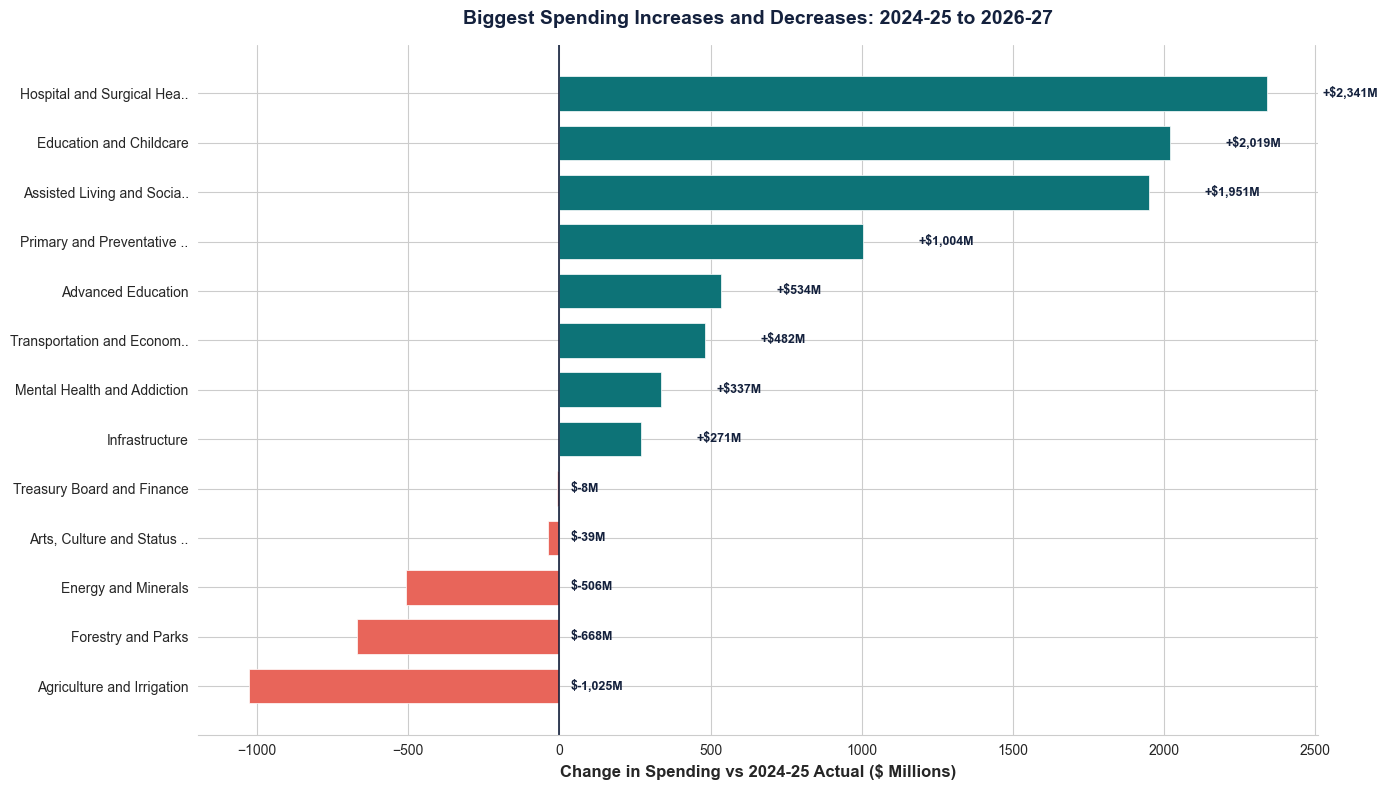

Saved: plots/expense_changes_tornado.png


In [3]:
# Diverging tornado chart of changes vs 2024-25
changes = df[['Ministry', 'Change_vs_2024']].copy()
changes = changes.sort_values('Change_vs_2024', ascending=True)

# Take top 8 increases and top 5 decreases for readability
top_inc = changes.nlargest(8, 'Change_vs_2024')
top_dec = changes.nsmallest(5, 'Change_vs_2024')
tornado_df = pd.concat([top_dec, top_inc]).drop_duplicates().sort_values('Change_vs_2024')

# Wrap long ministry names
tornado_df['Ministry'] = tornado_df['Ministry'].apply(lambda x: x[:25] + '..' if len(x) > 27 else x)

fig, ax = plt.subplots(figsize=(14, 8))

colors = [CORAL if v < 0 else TEAL for v in tornado_df['Change_vs_2024']]
bars = ax.barh(range(len(tornado_df)), tornado_df['Change_vs_2024'],
               color=colors, edgecolor='white', linewidth=0.5, height=0.7)

ax.set_yticks(range(len(tornado_df)))
ax.set_yticklabels(tornado_df['Ministry'], fontsize=10)
ax.axvline(x=0, color=NAVY, linewidth=1.2)

# Annotate with $ values
for i, (val, ministry) in enumerate(zip(tornado_df['Change_vs_2024'], tornado_df['Ministry'])):
    sign = '+' if val > 0 else ''
    if val >= 0:
        offset = 40
        ha = 'left'
    else:
        # Place negative labels at the right end of the bar (inside or just outside)
        offset = 8
        ha = 'left'
    ax.annotate(f'{sign}${val:,.0f}M', xy=(val if val >= 0 else 0, i),
                xytext=(offset, 0),
                textcoords='offset points', ha=ha, va='center',
                fontsize=9, fontweight='bold', color=NAVY)

ax.set_xlabel('Change in Spending vs 2024-25 Actual ($ Millions)', fontsize=12, fontweight='bold')
ax.set_title('Biggest Spending Increases and Decreases: 2024-25 to 2026-27',
             fontsize=14, fontweight='bold', color=NAVY, pad=15)

sns.despine(left=True)
plt.tight_layout()
plt.savefig('plots/expense_changes_tornado.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print('Saved: plots/expense_changes_tornado.png')

## Spending Composition by Category

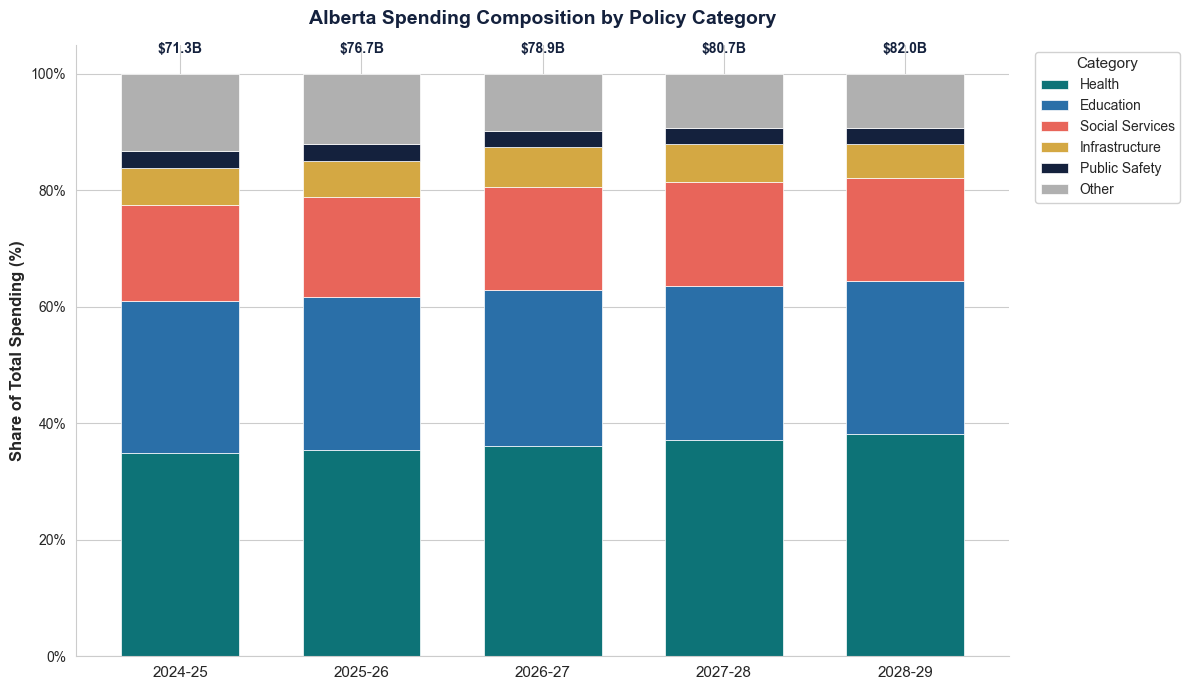

Saved: plots/expense_composition_categories.png


In [4]:
# Group ministries into policy categories
category_map = {
    'Health': ['Hospital and Surgical Health Services',
               'Primary and Preventative Health Services',
               'Mental Health and Addiction'],
    'Education': ['Education and Childcare', 'Advanced Education'],
    'Social Services': ['Assisted Living and Social Services',
                        'Children and Family Services'],
    'Infrastructure': ['Transportation and Economic Corridors',
                       'Infrastructure', 'Municipal Affairs'],
    'Public Safety': ['Justice',
                      'Public Safety and Emergency Services'],
}

assigned = [m for cat_list in category_map.values() for m in cat_list]

year_cols = ['2024-25_Actual', '2025-26_Forecast', '2026-27_Estimate',
             '2027-28_Target', '2028-29_Target']
year_labels = ['2024-25', '2025-26', '2026-27', '2027-28', '2028-29']

cat_data = {}
for cat, ministries in category_map.items():
    mask = df['Ministry'].isin(ministries)
    cat_data[cat] = df.loc[mask, year_cols].sum().values

other_mask = ~df['Ministry'].isin(assigned)
cat_data['Other'] = df.loc[other_mask, year_cols].sum().values

cat_df = pd.DataFrame(cat_data, index=year_labels)

# Convert to shares
cat_shares = cat_df.div(cat_df.sum(axis=1), axis=0) * 100

# Stacked bar chart
cat_colors = [TEAL, BLUE, CORAL, GOLD, NAVY, GREY]
cat_order = ['Health', 'Education', 'Social Services', 'Infrastructure', 'Public Safety', 'Other']

fig, ax = plt.subplots(figsize=(12, 7))
cat_shares[cat_order].plot(kind='bar', stacked=True, color=cat_colors, ax=ax,
                           edgecolor='white', linewidth=0.5, width=0.65)

ax.set_ylabel('Share of Total Spending (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_title('Alberta Spending Composition by Policy Category',
             fontsize=14, fontweight='bold', color=NAVY, pad=15)
ax.set_xticklabels(year_labels, rotation=0, fontsize=11)
ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=10, title_fontsize=11, framealpha=0.9)
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Add $ totals on top of each bar
for i, yr in enumerate(year_labels):
    total = cat_df.loc[yr].sum()
    ax.text(i, 103, f'${total/1000:.1f}B', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=NAVY)

sns.despine()
plt.tight_layout()
plt.savefig('plots/expense_composition_categories.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print('Saved: plots/expense_composition_categories.png')

## Growth Rate Analysis

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


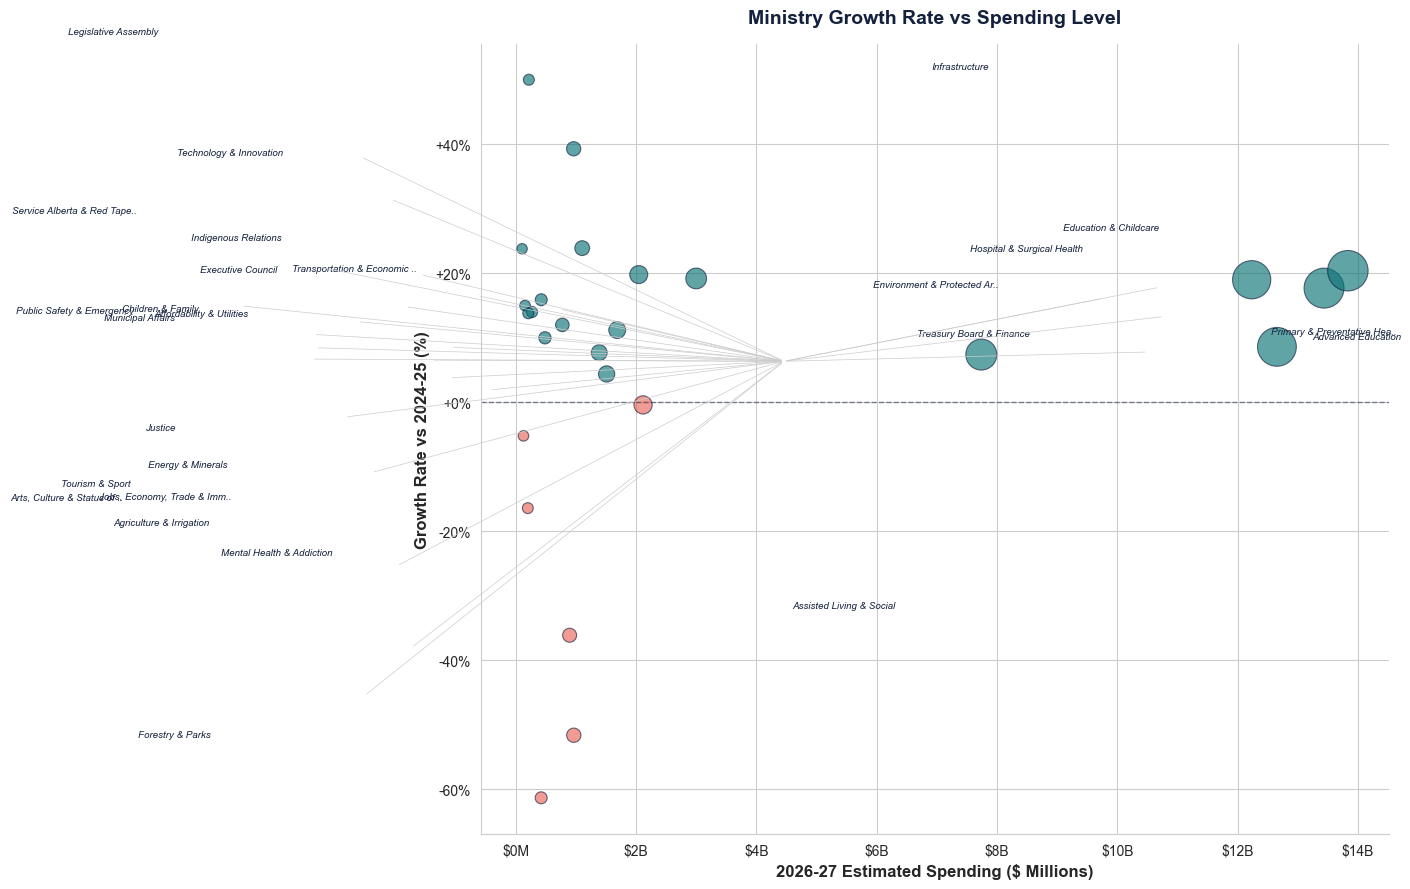

Saved: plots/expense_growth_vs_size.png


In [5]:
# Scatter/bubble: % growth rate vs 2026-27 spending level
scatter_df = df[['Ministry', '2026-27_Estimate', 'Pct_Change_vs_2024']].copy()
scatter_df = scatter_df.dropna()

fig, ax = plt.subplots(figsize=(14, 9))

sizes = scatter_df['2026-27_Estimate'] / scatter_df['2026-27_Estimate'].max() * 800 + 50
colors_scatter = [CORAL if v < 0 else TEAL for v in scatter_df['Pct_Change_vs_2024']]

ax.scatter(scatter_df['2026-27_Estimate'], scatter_df['Pct_Change_vs_2024'],
           s=sizes, c=colors_scatter, alpha=0.65, edgecolors=NAVY, linewidth=0.8)

ax.axhline(y=0, color=NAVY, linewidth=1, linestyle='--', alpha=0.5)

# Label all ministries with smart positioning
texts = []
for _, row in scatter_df.iterrows():
    short_name = row['Ministry'].replace(' and ', ' & ').replace(' Services', '')
    if len(short_name) > 28:
        short_name = short_name[:26] + '..'
    texts.append(ax.annotate(short_name,
                xy=(row['2026-27_Estimate'], row['Pct_Change_vs_2024']),
                xytext=(8, 6), textcoords='offset points',
                fontsize=7, color=NAVY, fontstyle='italic'))

# Try to use adjustText for automatic label repulsion
try:
    from adjustText import adjust_text
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='#cccccc', lw=0.5),
                force_points=0.3, force_text=0.5, expand_points=(1.5, 1.5))
except ImportError:
    pass  # Fall back to default positioning

ax.set_xlabel('2026-27 Estimated Spending ($ Millions)', fontsize=12, fontweight='bold')
ax.set_ylabel('Growth Rate vs 2024-25 (%)', fontsize=12, fontweight='bold')
ax.set_title('Ministry Growth Rate vs Spending Level',
             fontsize=14, fontweight='bold', color=NAVY, pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}B' if x >= 1000 else f'${x:.0f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))

sns.despine()
plt.tight_layout()
plt.savefig('plots/expense_growth_vs_size.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print('Saved: plots/expense_growth_vs_size.png')

## Key Expense Findings

- **Health dominates spending**: Hospital & Surgical, Primary & Preventative, and Mental Health combined account for ~36% of the 2026-27 budget (~$28.5B), up from ~$24.8B in 2024-25
- **Hospital & Surgical is the single largest increase**: +$2.3B (+20.4%), growing from $11.5B to $13.8B and projected to reach $15.1B by 2028-29
- **Education & Childcare sees second-largest growth**: +$2.0B (+17.7%), rising from $11.4B to $13.4B
- **Assisted Living & Social Services grows by $1.95B** (+19.0%), reflecting demographic and cost pressures
- **Agriculture & Irrigation sees the largest cut**: -$1.0B (-51.6%), likely due to one-time drought/disaster spending in 2024-25 not recurring
- **Forestry & Parks also drops sharply**: -$668M (-61.3%), similarly reflecting non-recurring wildfire expenditures
- **Total operating expense rises ~20%**: from $62.0B to $74.1B over the five-year window
- **Spending growth outpaces revenue**: expenses grow steadily while resource revenues decline, driving structural deficits
- **Health + Education + Social Services = ~60%** of all spending across the entire forecast period
- **Infrastructure spending increases modestly** (+$482M for Transportation), while capital-adjacent ministries remain relatively flat

In [6]:
# Save findings to text file
findings = """ALBERTA BUDGET 2026-29: EXPENSE ANALYSIS FINDINGS
================================================
Generated: 2026-02-26

HEADLINE: Total operating expense grows from $62.0B (2024-25) to $74.1B (2028-29), a 20% increase.

TOP SPENDING MINISTRIES (2026-27 Estimate):
  1. Hospital & Surgical Health Services:      $13,832M  (17.5% of total)
  2. Education & Childcare:                    $13,436M  (17.0%)
  3. Primary & Preventative Health Services:   $12,653M  (16.0%)
  4. Assisted Living & Social Services:        $12,233M  (15.5%)
  5. Advanced Education:                       $ 7,738M  ( 9.8%)

BIGGEST ABSOLUTE INCREASES (2024-25 to 2026-27):
  1. Hospital & Surgical Health Services:  +$2,341M  (+20.4%)
  2. Education & Childcare:                +$2,019M  (+17.7%)
  3. Assisted Living & Social Services:    +$1,951M  (+19.0%)
  4. Primary & Preventative Health:        +$1,004M  (+ 8.6%)
  5. Advanced Education:                   +$  534M  (+ 7.4%)

BIGGEST DECREASES:
  1. Agriculture & Irrigation:             -$1,025M  (-51.6%)
  2. Forestry & Parks:                     -$  668M  (-61.3%)
  3. Energy & Minerals:                    -$  506M  (-36.1%)

CATEGORY ANALYSIS (2026-27):
  Health (3 ministries):        ~$28.5B  (~36% of spending)
  Education (2 ministries):     ~$21.2B  (~27%)
  Social Services (2 min.):     ~$13.9B  (~18%)
  Infrastructure (3 min.):      ~$ 5.3B  (~ 7%)
  Public Safety (2 min.):       ~$ 2.3B  (~ 3%)
  Other (14 ministries):        ~$ 7.6B  (~10%)

KEY STRUCTURAL OBSERVATIONS:
  - Health + Education + Social Services = ~60% of all spending
  - Spending growth consistently outpaces revenue growth
  - Large apparent cuts in Agriculture and Forestry reflect
    non-recurring disaster spending in 2024-25, not true program cuts
  - Healthcare spending projected to reach $31.3B by 2028-29,
    up from $24.8B in 2024-25 (+26%)
  - The sustained spending growth trajectory locks in structural
    deficits unless resource revenues recover significantly
"""

with open('expense_findings.txt', 'w') as f:
    f.write(findings)

print('Saved: expense_findings.txt')
print(findings)

Saved: expense_findings.txt
ALBERTA BUDGET 2026-29: EXPENSE ANALYSIS FINDINGS
Generated: 2026-02-26

HEADLINE: Total operating expense grows from $62.0B (2024-25) to $74.1B (2028-29), a 20% increase.

TOP SPENDING MINISTRIES (2026-27 Estimate):
  1. Hospital & Surgical Health Services:      $13,832M  (17.5% of total)
  2. Education & Childcare:                    $13,436M  (17.0%)
  3. Primary & Preventative Health Services:   $12,653M  (16.0%)
  4. Assisted Living & Social Services:        $12,233M  (15.5%)
  5. Advanced Education:                       $ 7,738M  ( 9.8%)

BIGGEST ABSOLUTE INCREASES (2024-25 to 2026-27):
  1. Hospital & Surgical Health Services:  +$2,341M  (+20.4%)
  2. Education & Childcare:                +$2,019M  (+17.7%)
  3. Assisted Living & Social Services:    +$1,951M  (+19.0%)
  4. Primary & Preventative Health:        +$1,004M  (+ 8.6%)
  5. Advanced Education:                   +$  534M  (+ 7.4%)

BIGGEST DECREASES:
  1. Agriculture & Irrigation:           